## Homework 2

---

The following problems are from the textbook ```An introduction to statistical learning. New
York: Springer; 2023 Jun. ```

An electronic version is freely available at: https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html


### Problem 

Page 121, no.3

Suppose we have a data set with five predictors, X1 = GPA, X2 = IQ,
X3 = Gender (1 for Female and 0 for Male), X4 = Interaction between
GPA and IQ, and X5 = Interaction between GPA and Gender. The
response is starting salary after graduation (in thousands of dollars).
Suppose we use least squares to fit the model, and get $\beta_0 = 50, \beta_1 =
20, \beta_2 = 0.07, \beta_3 = 35, \beta_4 = 0.01, \beta_5 = −10$.

(a) Which answer is correct, and why?
- i. For a fixed value of IQ and GPA, males earn more on average
than females.
- ii. For a fixed value of IQ and GPA, females earn more on
average than males.
- iii. For a fixed value of IQ and GPA, males earn more on average
than females provided that the GPA is high enough.
- iv. For a fixed value of IQ and GPA, females earn more on
average than males provided that the GPA is high enough.


***You answer here***:

The starting salary $Y$ is given by:$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \beta_5 X_5$$

Plugging in the given values, we get: 
$$Y = 50 + 20(\text{GPA}) + 0.07(\text{IQ}) + 35(\text{Gender}) + 0.01(\text{GPA} \times \text{IQ}) - 10(\text{GPA} \times \text{Gender})$$

To see which gender earns more, compare the equations for Males ($\text{Gender} = 0$) and Females ($\text{Gender} = 1$) while keeping GPA and IQ constant.

For Males ($\text{Gender} = 0$):
$$Y_M = 50 + 20(\text{GPA}) + 0.07(\text{IQ}) + 35(0) + 0.01(\text{GPA} \times \text{IQ}) - 10(\text{GPA} \times 0)$$
$$Y_M = 50 + 20(\text{GPA}) + 0.07(\text{IQ}) + 0.01(\text{GPA} \times \text{IQ})$$

For Females ($\text{Gender} = 1$):
$$Y_F = 50 + 20(\text{GPA}) + 0.07(\text{IQ}) + 35(1) + 0.01(\text{GPA} \times \text{IQ}) - 10(\text{GPA} \times 1)$$
$$Y_F = (50 + 35) + (20 - 10)\text{GPA} + 0.07(\text{IQ}) + 0.01(\text{GPA} \times \text{IQ})$$
$$Y_F = 85 + 10(\text{GPA}) + 0.07(\text{IQ}) + 0.01(\text{GPA} \times \text{IQ})$$

Substracting Y_M from Y_F, we get,
$$Y_F - Y_M = 85 - 50 + (10-20)(\text{GPA}) + (0.07-0.07)(\text{IQ}) + (0.01 - 0.01)(\text{GPA} \times \text{IQ})$$
$$Y_F - Y_M = 35−10(\text{GPA})$$

Thus, Females earn more when: $$35−10(\text{GPA}) > 0  ⇒ 3.5 > \text{GPA}$$
Males earn more when: $$35−10(\text{GPA}) < 0  ⇒ 3.5 < \text{GPA}$$

The analysis shows that if GPA < 3.5, Females earn more on average and if GPA > 3.5, Males earn more on average. Therefore, the correct answer is:

(iii) For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.


(b) Predict the salary of a female with IQ of 110 and a GPA of 4.0.

- Write a function to calculate the salary

In [1]:
import numpy as np
# write funcion to predict salary
def predict_salary(GPA, IQ, Gender):
    beta0 = 50
    beta1 = 20
    beta2 = 0.07
    beta3 = 35
    beta4 = 0.01
    beta5 = -10
    
    salary = (
        beta0
        + beta1 * GPA
        + beta2 * IQ
        + beta3 * Gender
        + beta4 * GPA * IQ
        + beta5 * GPA * Gender
    )
    
    return salary  # in thousands of dollars
# Predict the salary of a Female with IQ 110 and GPA 4.0
predicted_salary = predict_salary(4.0, 110, 1)
print(f"Predicted salary: ${predicted_salary * 1000:.2f}")


Predicted salary: $137100.00


(c) True or false: Since the coefficient for the GPA/IQ interaction
term is very small, there is very little evidence of an interaction
effect. Justify your answer.

***You answer here***:

(c) False
The magnitude of a coefficient does not directly give evidence for an interaction. Whether an interaction is significant depends on its statistically significance (e.g., t-statistic / p-value), not on the raw magnitude of the coefficient.

For example, assume $$\text{GPA} = 4 \text{ and IQ} = 110$$
The interaction term gives: $$0.01(GPA \times IQ) = 0.01(4 \times 110) = 4.4$$
Thus the starting salary is shifted by $4.4 thousand dollars by the interaction term, which is not negligible. 

---
#### Problem 

Page 127, no.15. 

This problem involves the **Boston** data set. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# read data into a dataframe
boston = pd.read_csv('./Boston.csv')  # suppose your data is within the same folder as this 

boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = boston.copy()
y = df["crim"]
predictors = df.drop("crim", axis=1)

rows = []
for col in predictors.columns:
    X = sm.add_constant(predictors[[col]])  # adds intercept
    model = sm.OLS(y, X).fit()

    rows.append({
        "predictor": col,
        "beta_0": model.params["const"],
        "beta_1": model.params[col],
        "p_value": model.pvalues[col],
        "r2": model.rsquared
    })

simple_lr_results = pd.DataFrame(rows)
print(simple_lr_results)

sig_predictor = simple_lr_results[simple_lr_results["p_value"] < 0.05].sort_values("p_value")
print("\nStatistically significant predictors in descending order of significance (p < 0.05):")
print(sig_predictor[["predictor", "beta_1", "p_value", "r2"]])



   predictor     beta_0     beta_1       p_value        r2
0         zn   4.453694  -0.073935  5.506472e-06  0.040188
1      indus  -2.063743   0.509776  1.450349e-21  0.165310
2       chas   3.744447  -1.892777  2.094345e-01  0.003124
3        nox -13.719882  31.248531  3.751739e-23  0.177217
4         rm  20.481804  -2.684051  6.346703e-07  0.048069
5        age  -3.777906   0.107786  2.854869e-16  0.124421
6        dis   9.499262  -1.550902  8.519949e-19  0.144149
7        rad  -2.287159   0.617911  2.693844e-56  0.391257
8        tax  -8.528369   0.029742  2.357127e-47  0.339614
9    ptratio -17.646933   1.151983  2.942922e-11  0.084068
10     lstat  -3.330538   0.548805  2.654277e-27  0.207591
11      medv  11.796536  -0.363160  1.173987e-19  0.150780

Statistically significant predictors in descending order of significance (p < 0.05):
   predictor     beta_1       p_value        r2
7        rad   0.617911  2.693844e-56  0.391257
8        tax   0.029742  2.357127e-47  0.339614
10 

The results show that at the 5% significance level (α = 0.05) all predictors except CHAS show statistically significant associations with crime rate.

Significant predictors with p-value < 0.05 (in descending order):
1. rad
2. tax
3. lstat
4. nox
5. indus
6. medv
7. dis
8. age
9. ptratio
10. rm
11. zn

Among them the strongest single predictors of crime rate are rad (R² = 0.391) and tax (R² = 0.340).

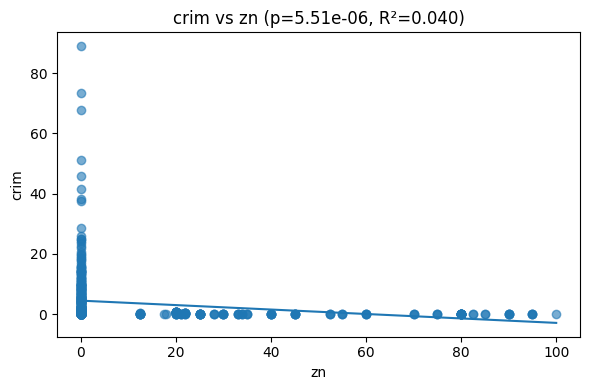

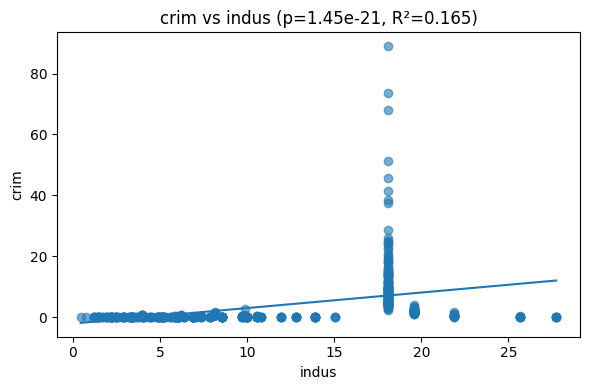

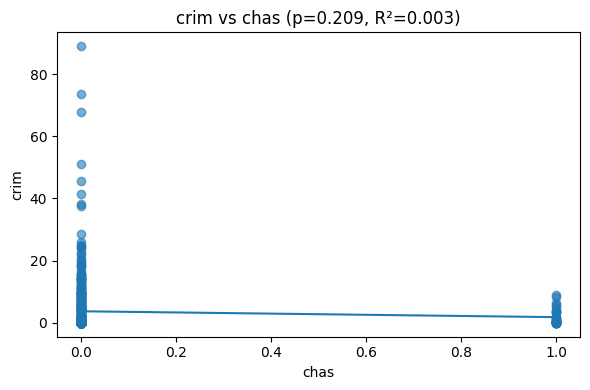

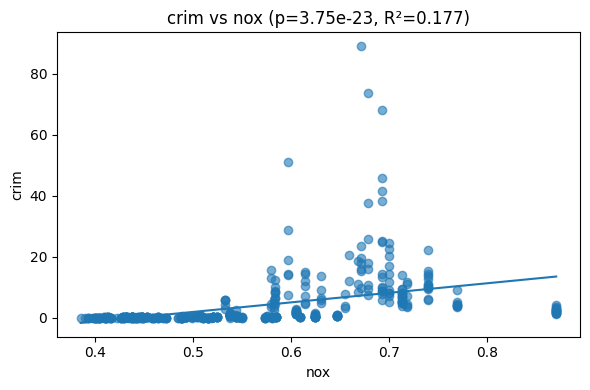

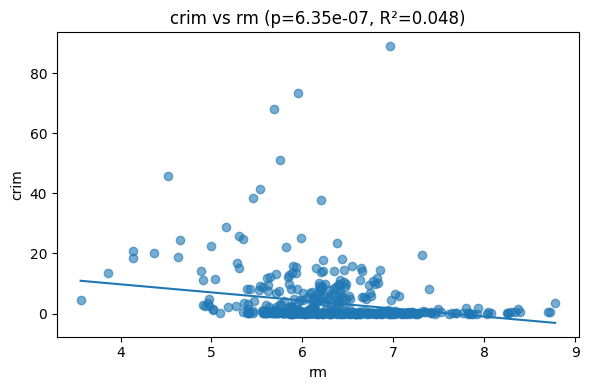

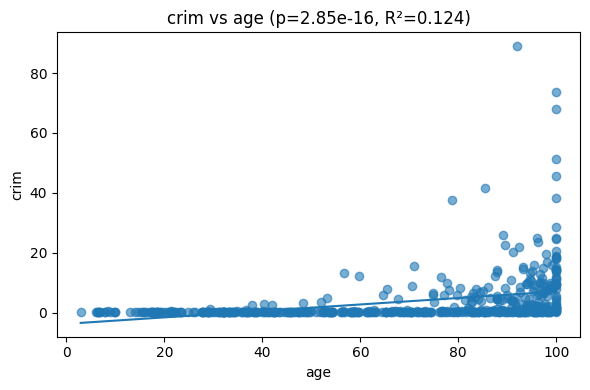

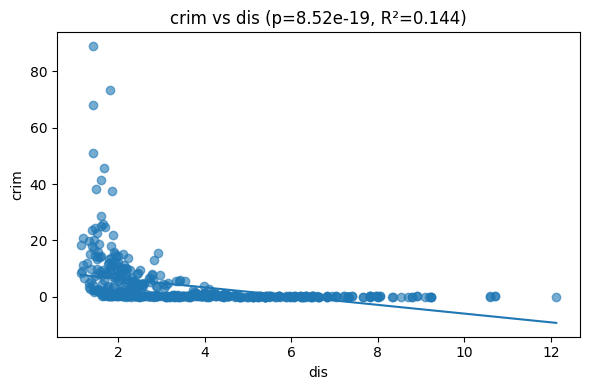

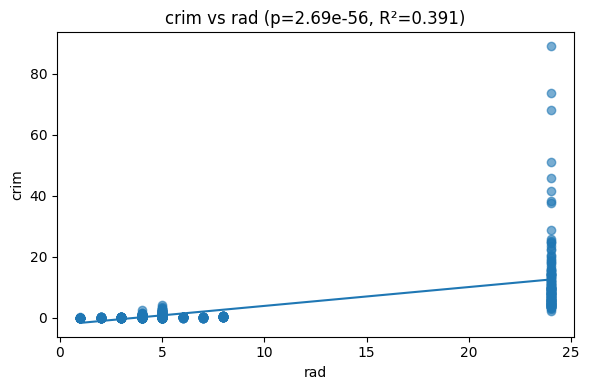

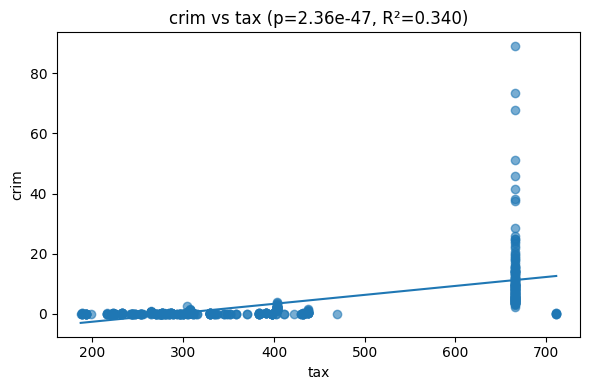

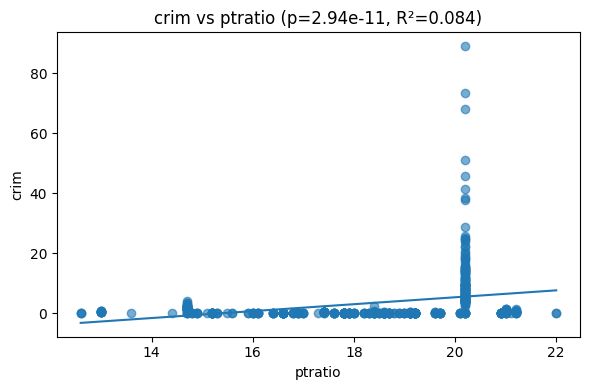

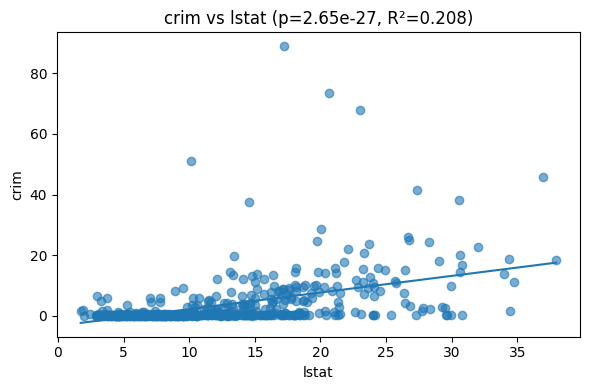

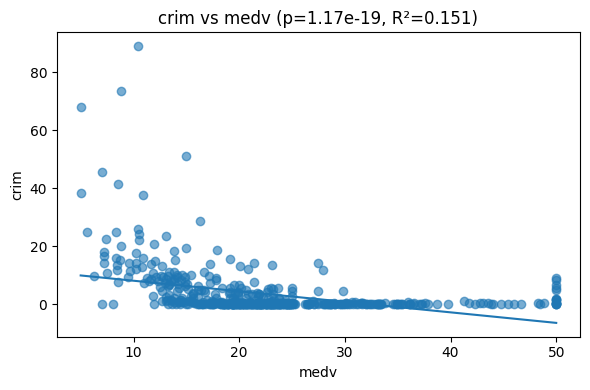

In [26]:
import numpy as np
import matplotlib.pyplot as plt

coef_map = simple_lr_results.set_index("predictor")[["beta_0", "beta_1", "p_value", "r2"]]

for col in predictors.columns:
    b0 = coef_map.loc[col, "beta_0"]
    b1 = coef_map.loc[col, "beta_1"]
    p  = coef_map.loc[col, "p_value"]
    r2 = coef_map.loc[col, "r2"]

    x = df[col].to_numpy()
    x_grid = np.linspace(x.min(), x.max(), 200)
    y_hat = b0 + b1 * x_grid

    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["crim"], alpha=0.6)
    plt.plot(x_grid, y_hat)
    plt.xlabel(col)
    plt.ylabel("crim")
    plt.title(f"crim vs {col} (p={p:.3g}, R²={r2:.3f})")
    plt.tight_layout()
    plt.show()

The scatter plots support the regression results by showing clear linear trends for most significant predictors. Predictors such as rad and tax show tight clustering of data points around the fitted line, consistent with their smaller p-values and higher R² values. Other significant predictors show weaker but still noticeable trends. In contrast, CHAS shows no clear pattern with all data points only clustered around chas value 0 or 1. This matches its non-significant result. Overall, the visual patterns align with the statistical findings.

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. 

In [29]:
# fit a multiple regression model using all the predictors to predict the response
import statsmodels.api as sm

# Response
y = df["crim"]

# All predictors
X = df.drop("crim", axis=1)

# Add intercept
X = sm.add_constant(X)

# Fit multiple regression
multiple_lr_results = sm.OLS(y, X).fit()

print(multiple_lr_results.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.03e-56
Time:                        21:37:10   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

Although except for chas, all other predictors produced statisically significant relation in simple linear regression of individual predictors, only a number of them remain significant in multiple linear regression of all variables. This highlights the fact that influence of some predictors in simple regression resulted from multicollinearity with other predictors.

The multiple regression model provides a better prediction of crime rate than any single predictor model, but multicollinearity appears to influence coefficient estimates.

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

         simple_coef  multiple_coef
zn         -0.073935       0.045710
indus       0.509776      -0.058350
chas       -1.892777      -0.825378
nox        31.248531      -9.957587
rm         -2.684051       0.628911
age         0.107786      -0.000848
dis        -1.550902      -1.012247
rad         0.617911       0.612465
tax         0.029742      -0.003776
ptratio     1.151983      -0.304073
lstat       0.548805       0.138801
medv       -0.363160      -0.220056


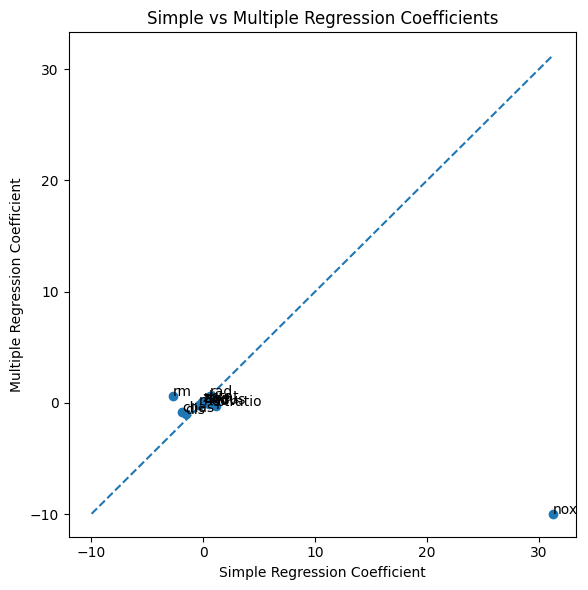

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- Simple regression coefficients (from part a)
simple_coefs = simple_lr_results.set_index("predictor")["beta_1"]

# ---- Multiple regression coefficients (from part b)
multi_coefs = multiple_lr_results.params.drop("const")  # remove intercept

# ---- Combine into one DataFrame
coef_compare = pd.DataFrame({
    "simple_coef": simple_coefs,
    "multiple_coef": multi_coefs
})

print(coef_compare)

# ---- Plot
plt.figure(figsize=(6,6))
plt.scatter(coef_compare["simple_coef"], coef_compare["multiple_coef"])

# Add 45-degree reference line
min_val = min(coef_compare.min())
max_val = max(coef_compare.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# Label each point
for predictor in coef_compare.index:
    plt.text(coef_compare.loc[predictor, "simple_coef"],
             coef_compare.loc[predictor, "multiple_coef"],
             predictor)

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")
plt.tight_layout()
plt.show()

The coefficients obtain from simple and multiple regression models are different because:
- In the simple regression model, the coefficient of a predictor reflects the change in the response variable due to a unit change in the predictor without considering other predictors. 
- In the multiple regression model, the same coefficient represents the change in the response variable due to a unit change in the predictor while holding other predictors constant.

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form

$$Y = \beta_0 + \beta_1*X + \beta_2*X^2 + \beta_3*X^3 + \epsilon.$$

In [34]:
# for each predictor fit a polynomial regression of degree 3
import numpy as np
import pandas as pd
import statsmodels.api as sm

y = df["crim"]
predictors = df.drop("crim", axis=1)

poly_results = []

for col in predictors.columns:
    X_poly = pd.DataFrame({
        "X": df[col],
        "X2": df[col]**2,
        "X3": df[col]**3
    })

    X_poly = sm.add_constant(X_poly)
    model_poly = sm.OLS(y, X_poly).fit()

    poly_results.append({
        "predictor": col,
        "p(X)": model_poly.pvalues["X"],
        "p(X^2)": model_poly.pvalues["X2"],
        "p(X^3)": model_poly.pvalues["X3"],
        "R2": model_poly.rsquared
    })

poly_results_df = pd.DataFrame(poly_results)

print(f"\nPolynomial (degree 3) regression results:")
print(poly_results_df)

nonlinear = poly_results_df[
    (poly_results_df["p(X^2)"] < 0.05) | 
    (poly_results_df["p(X^3)"] < 0.05)
]

print("\nPredictors showing evidence of non-linearity (p < 0.05):")
print(nonlinear)


Polynomial (degree 3) regression results:
   predictor          p(X)        p(X^2)        p(X^3)        R2
0         zn  2.612296e-03  9.375050e-02  2.295386e-01  0.058242
1      indus  5.297064e-05  3.420187e-10  1.196405e-12  0.259658
2       chas  6.813326e-01  6.813326e-01  6.813326e-01  0.003121
3        nox  2.758372e-13  6.811300e-15  6.961110e-16  0.296978
4         rm  2.117564e-01  3.641094e-01  5.085751e-01  0.067786
5        age  1.426608e-01  4.737733e-02  6.679915e-03  0.174231
6        dis  6.374792e-18  4.941214e-12  1.088832e-08  0.277825
7        rad  6.234175e-01  6.130099e-01  4.823138e-01  0.400037
8        tax  1.097075e-01  1.374682e-01  2.438507e-01  0.368882
9    ptratio  3.028663e-03  4.119552e-03  6.300514e-03  0.113782
10     lstat  3.345300e-01  6.458736e-02  1.298906e-01  0.217932
11      medv  2.637707e-28  3.260523e-18  1.046510e-12  0.420200

Predictors showing evidence of non-linearity (p < 0.05):
   predictor          p(X)        p(X^2)        p(X^3)

The results of p-value at 95% significance level (p<0.05) of quadratic or cubic terms in the polynomial regression models indicate that there is evidence of nonlinear association between crime rate and several predictors. These predictors include indus, nox, age, dis, ptratio, and medv. 

---

#### Build linear models using the Boston dataset

In [35]:
# meaning of each predictor
import pandas as pd

# dreate a list of tuples with variable names and descriptions
var_desc = [('crim', 'per capita crime rate by town'),
            ('zn', 'proportion of residential land zoned for lots over 25,000 sq.ft.'),
            ('indus', 'proportion of non-retail business acres per town.'),
            ('chas', 'Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).'),
            ('nox', 'nitrogen oxides concentration (parts per 10 million).'),
            ('rm', 'average number of rooms per dwelling.'),
            ('age', 'proportion of owner-occupied units built prior to 1940.'),
            ('dis', 'weighted mean of distances to five Boston employment centers.'),
            ('rad', 'index of accessibility to radial highways.'),
            ('tax', 'full-value property-tax rate per $10,000.'),
            ('ptratio', 'pupil-teacher ratio by town.'),
            ('lstat', 'lower status of the population (percent).'),
            ('mdev', 'median value of owner-occupied homes in $1000s.')]

# dreate a DataFrame with the variable descriptions
df = pd.DataFrame(var_desc, columns=['Variable', 'Description'])

# display the DataFrame as a table in Jupyter notebook
display(df)

,Variable,Description
0,crim,per capita crime rate by town
1,zn,proportion of residential land zoned for lots ...
2,indus,proportion of non-retail business acres per town.
3,chas,Charles River dummy variable (= 1 if tract bou...
4,nox,nitrogen oxides concentration (parts per 10 mi...
5,rm,average number of rooms per dwelling.
6,age,proportion of owner-occupied units built prior...
7,dis,weighted mean of distances to five Boston empl...
8,rad,index of accessibility to radial highways.
9,tax,"full-value property-tax rate per $10,000."


In [36]:
# load the 'Boston.csv' file 
boston = pd.read_csv('./Boston.csv')

# describe the dataframe
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


- Build a full multiple linear regression model using 'sklean' and 'statsmodels' respectively to learn the relation between the crime rate (the 'crim' column) and other predictors
- Plot the residual and studentized residual to determine whether the assumptions of linear regression are violated


In [46]:
# build a full multiple linear regression model using 'sklean'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = boston.copy()
# All predictors
X = df.drop("crim", axis=1)
# Response
y = df["crim"]

# Fit model
model_sklearn = LinearRegression()
model_sklearn.fit(X, y)

# Predictions
y_pred = model_sklearn.predict(X)

print("Sklearn Model")
print("Intercept:", model_sklearn.intercept_)
print("Coefficients:", model_sklearn.coef_)
print("R²:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))



Sklearn Model
Intercept: 13.778393786344163
Coefficients: [ 4.57100386e-02 -5.83501107e-02 -8.25377552e-01 -9.95758655e+00
  6.28910662e-01 -8.48279066e-04 -1.01224674e+00  6.12465311e-01
 -3.77564652e-03 -3.04072757e-01  1.38800597e-01 -2.20056359e-01]
R²: 0.44933781134899065
MSE: 40.661094063950145


In [41]:
# Build a full multiple linear regression model using 'statsmodels' 
import statsmodels.api as sm

# All predictors
X = df.drop("crim", axis=1)
# Response
y = df["crim"]
# Add intercept
X = sm.add_constant(X)
# Fit multiple regression
model_statsmodels = sm.OLS(y, X).fit()
print("Statsmodels Model Summary:")
print(model_statsmodels.summary())


Statsmodels Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.03e-56
Time:                        22:09:09   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784    

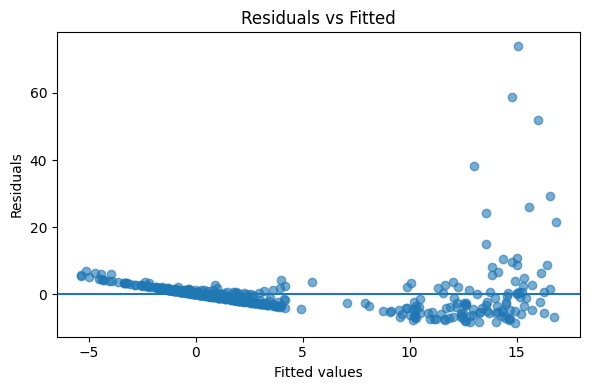

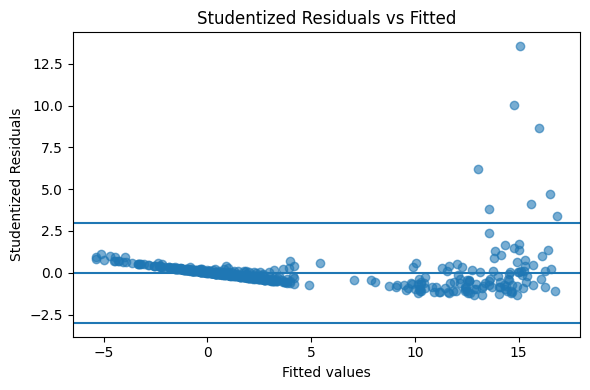

In [45]:
# plot the residual and studentized residual to determine whether the assumptions of linear regression are violated
import matplotlib.pyplot as plt

# Residuals vs Fitted
fitted_vals = model_statsmodels.fittedvalues
residuals = model_statsmodels.resid

plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# Studentized Residuals vs Fitted
influence = model_statsmodels.get_influence()
student_resid = influence.resid_studentized_external

plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, student_resid, alpha=0.6)
plt.axhline(0)
plt.axhline(3)
plt.axhline(-3)
plt.xlabel("Fitted values")
plt.ylabel("Studentized Residuals")
plt.title("Studentized Residuals vs Fitted")
plt.tight_layout()
plt.show()

The residual and studentized residual plots indicate violations of several linear regression assumptions:

1. Homoscedascity: The residuals vs fitted plot shows that at a higher crime rate variance increases with fitted values. This indicates violation of homoscedasticity. 
2. Normality: The residual plot shows large right tail in residuals, which indicate possible violation of normality.
3. Outlier: The studentized residual plot reveals multiple extreme outliers outside the range $-3 \le \text{studentized residual} \le 3$. 
4. Nonlinearity: Curvature in the residual pattern suggests possible nonlinearity. 

Overall, although while the model explains a substantial portion of variation in crime rate, several linear regression assumptions appear to be violated.

- Identify predictors that are highly correlated with other predictors, remove them and build a new linear regression model and compare the performance of the new model to the full model
- Output the results of the linear model fitted using the 'statsmodels'

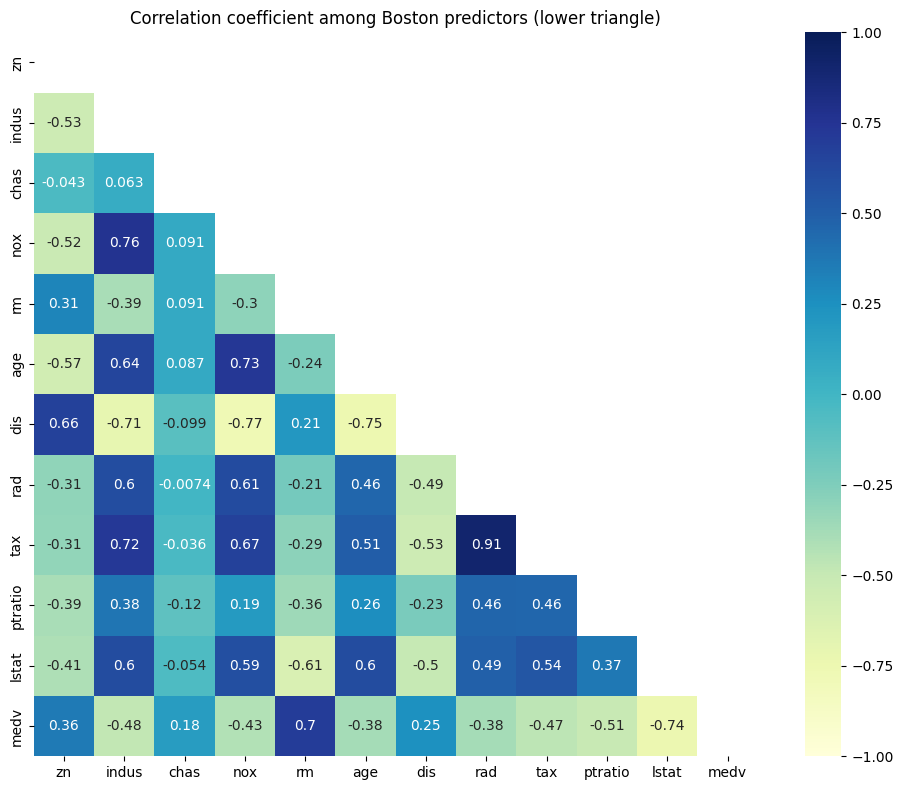

Highly correlated pairs (|corr| > 0.75):
('nox', 'indus', 0.7636514469209139)
('dis', 'nox', 0.7692301132258282)
('tax', 'rad', 0.9102281885331865)

Predictors to remove due to high correlation: ['dis', 'indus', 'tax']

====Model comparison====
Full model:    p=12 predictors | R²=0.4493 | Adj R²=0.4359 | AIC=3336.83 | BIC=3391.78
Reduced model: p=9 predictors | R²=0.4344 | Adj R²=0.4241 | AIC=3344.37 | BIC=3386.64


In [55]:
# identify predictors that are highly correlated with other predictors, remove them and build a new linear regression model and compare performance
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# -------------------------
# 1) Correlation heatmap (predictors only)
# -------------------------
X = df.drop("crim", axis=1)

corr_pred = X.corr()  # predictors-only corr for heatmap
mask = np.triu(np.ones_like(corr_pred, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pred, mask=mask, annot=True, vmin=-1, vmax=1, cmap="YlGnBu", square=True)
plt.title("Correlation coefficient among Boston predictors (lower triangle)")
plt.tight_layout()
plt.show()

# -------------------------
# 2) Find highly correlated predictor pairs (|corr| > 0.75)
# -------------------------
corr_pred_abs = corr_pred.abs()
upper = corr_pred_abs.where(np.triu(np.ones(corr_pred_abs.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.75]

print("Highly correlated pairs (|corr| > 0.75):")
for pair in high_corr:
    print(pair)

# -------------------------
# 3) Use your rule: drop the one with lower |corr with crim|
#    IMPORTANT: need corr matrix that includes crim
# -------------------------
corr_all_abs = df.corr().abs()  # includes 'crim'

to_remove = set()
for col1, col2, corr_val in high_corr:
    c1 = corr_all_abs.loc["crim", col1]
    c2 = corr_all_abs.loc["crim", col2]
    to_remove.add(col1 if c1 < c2 else col2)

print(f"\nPredictors to remove due to high correlation: {sorted(to_remove)}")

# -------------------------
# 4) Fit full and reduced models (statsmodels)
# -------------------------
y = df["crim"]

X_full = df.drop("crim", axis=1)
X_reduced = X_full.drop(columns=list(to_remove), errors="ignore")

X_full_sm = sm.add_constant(X_full)
X_reduced_sm = sm.add_constant(X_reduced)

model_full = sm.OLS(y, X_full_sm).fit()
model_reduced = sm.OLS(y, X_reduced_sm).fit()

# -------------------------
# 5) Compare model performance
# -------------------------
print("\n====Model comparison====")
print(f"Full model:    p={X_full.shape[1]} predictors | R²={model_full.rsquared:.4f} | Adj R²={model_full.rsquared_adj:.4f} | AIC={model_full.aic:.2f} | BIC={model_full.bic:.2f}")
print(f"Reduced model: p={X_reduced.shape[1]} predictors | R²={model_reduced.rsquared:.4f} | Adj R²={model_reduced.rsquared_adj:.4f} | AIC={model_reduced.aic:.2f} | BIC={model_reduced.bic:.2f}")


In [56]:
# Output the results of the linear model fitted using the 'statsmodels'
print("\n====Full model summary====")
print(model_full.summary())

print("\n====Reduced model summary====")
print(model_reduced.summary())


====Full model summary====
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           2.03e-56
Time:                        23:16:26   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784   

- Build a forward subset selection model between crime rates and the predictors using 10-fold cross-validation.


- Output coefficients and R-squared


- Plot the relation beween the model performance (r-squared) and the number of predictors




Step  1: added      rad | mean 10-fold CV R² = 0.4689
Step  2: added    lstat | mean 10-fold CV R² = 0.5083
Step  3: added       zn | mean 10-fold CV R² = 0.5113
Step  4: added      dis | mean 10-fold CV R² = 0.5181
Step  5: added      nox | mean 10-fold CV R² = 0.5216
Step  6: added  ptratio | mean 10-fold CV R² = 0.5224
Step  7: added     chas | mean 10-fold CV R² = 0.5233
Step  8: added       rm | mean 10-fold CV R² = 0.5228
Step  9: added      tax | mean 10-fold CV R² = 0.5223
Step 10: added    indus | mean 10-fold CV R² = 0.5212
Step 11: added      age | mean 10-fold CV R² = 0.5194
Step 12: added     medv | mean 10-fold CV R² = 0.5064

Forward Selection Results (by model size):
     k added_predictor     cv_r2
0    1             rad  0.468883
1    2           lstat  0.508271
2    3              zn  0.511257
3    4             dis  0.518114
4    5             nox  0.521562
5    6         ptratio  0.522375
6    7            chas  0.523271
7    8              rm  0.522786
8    9     

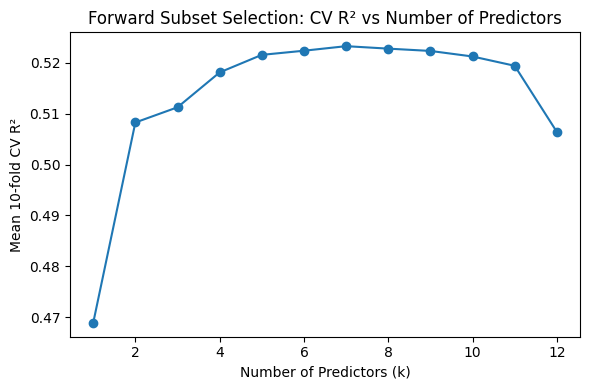


Best model size (max CV R²): 7
Best predictors: ['rad', 'lstat', 'zn', 'dis', 'nox', 'ptratio', 'chas']
Best mean 10-fold CV R²: 0.5232706094253337

=== Best Model Fit on Full Data ===
Intercept: 3.818931633588096

Coefficients (sorted by |value|):
predictor  coefficient
      nox    -7.769552
     chas    -1.538912
      dis    -0.629844
      rad     0.542967
    lstat     0.266966
  ptratio    -0.128177
       zn     0.035524

R² on full data: 0.4331403608411547


In [65]:
# Forward subset selection with 10-fold CV (optimize CV R^2),
# output coefficients + R^2 for the best model, and plot CV R^2 vs # predictors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# define response and predictors
y = df["crim"]
X = df.drop(columns=["crim"])
predictors = list(X.columns)

kf = KFold(n_splits=10, shuffle=True, random_state=42)


# define a helper function to compute mean CV R^2 for a given predictor set
def cv_r2_for_predictors(X_sub: pd.DataFrame, y: pd.Series, kf: KFold) -> float:
    scores = []
    for train_idx, test_idx in kf.split(X_sub):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores.append(r2_score(y_test, y_pred))

    return float(np.mean(scores))


# Forward selection using CV R^2
remaining = predictors.copy()
selected = []
cv_r2_by_k = []

while remaining:
    best_score = -np.inf
    best_pred = None

    for pred in remaining:
        trial_preds = selected + [pred]
        score = cv_r2_for_predictors(X[trial_preds], y, kf)

        if score > best_score:
            best_score = score
            best_pred = pred

    selected.append(best_pred)
    remaining.remove(best_pred)
    cv_r2_by_k.append(best_score)

    print(f"Step {len(selected):2d}: added {best_pred:>8s} | mean 10-fold CV R² = {best_score:.4f}")



# Results table + plot (CV R^2 vs # predictors)
results = pd.DataFrame({
    "k": range(1, len(selected) + 1),
    "added_predictor": selected,
    "predictors_in_model": [selected[:i] for i in range(1, len(selected) + 1)],
    "cv_r2": cv_r2_by_k
})

print("\nForward Selection Results (by model size):")
print(results[["k", "added_predictor", "cv_r2"]])

plt.figure(figsize=(6, 4))
plt.plot(results["k"], results["cv_r2"], marker="o")
plt.xlabel("Number of Predictors (k)")
plt.ylabel("Mean 10-fold CV R²")
plt.title("Forward Subset Selection: CV R² vs Number of Predictors")
plt.tight_layout()
plt.show()


# Choose best model size (max CV R^2)
best_idx = int(np.argmax(cv_r2_by_k))          # 0-based
best_k = best_idx + 1
best_predictors = selected[:best_k]
best_cv_r2 = cv_r2_by_k[best_idx]

print("\nBest model size (max CV R²):", best_k)
print("Best predictors:", best_predictors)
print("Best mean 10-fold CV R²:", best_cv_r2)



# Fit best model on full data and output coefficients + R^2
final_model = LinearRegression()
final_model.fit(X[best_predictors], y)

coef_df = pd.DataFrame({
    "predictor": best_predictors,
    "coefficient": final_model.coef_
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

r2_full_fit = final_model.score(X[best_predictors], y)

print("\n=== Best Model Fit on Full Data ===")
print("Intercept:", final_model.intercept_)
print("\nCoefficients (sorted by |value|):")
print(coef_df.to_string(index=False))
print("\nR² on full data:", r2_full_fit)

Build a LASSO and ridge regression model using 10-fold cross validation to predict the crime rate

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale 
from sklearn.linear_model import RidgeCV, Lasso, LassoCV
from sklearn.metrics import r2_score

# write a function to get the coefficients and r2 to avoid repetition
def get_coefs_r2(reg_model, X_train, X_test, y_train, y_test):
    reg_model.fit(X_train, y_train)
    coefs = reg_model.coef_
    r2_train = reg_model.score(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    r2_pred = r2_score(y_test, y_pred)
    
    return coefs, r2_train, r2_pred



In [67]:
# build a LASSO and ridge regression model using 10-fold cross validation to predict the crime rate
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score

# Define X and y
X = df.drop("crim", axis=1)
y = df["crim"]

feature_names = X.columns

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


# Standardize predictors (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Ridge Regression with 10-fold CV
alphas = np.logspace(-4, 4, 200)  # grid of lambdas/alphas

ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_coefs, ridge_r2_train, ridge_r2_test = get_coefs_r2(
    ridge_cv, X_train_scaled, X_test_scaled, y_train, y_test
)

print("=== Ridge Regression (10-fold CV) ===")
print("Chosen alpha:", ridge_cv.alpha_)
print("Train R^2:", ridge_r2_train)
print("Test  R^2:", ridge_r2_test)

ridge_coef_df = pd.DataFrame({
    "predictor": feature_names,
    "coef": ridge_coefs
}).sort_values("coef", key=lambda s: s.abs(), ascending=False)

print("\nRidge coefficients (sorted by |coef|):")
print(ridge_coef_df.to_string(index=False))


# LASSO Regression with 10-fold CV
lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=200000, random_state=42)
lasso_coefs, lasso_r2_train, lasso_r2_test = get_coefs_r2(
    lasso_cv, X_train_scaled, X_test_scaled, y_train, y_test
)

print("\n=== LASSO Regression (10-fold CV) ===")
print("Chosen alpha:", lasso_cv.alpha_)
print("Train R^2:", lasso_r2_train)
print("Test  R^2:", lasso_r2_test)

lasso_coef_df = pd.DataFrame({
    "predictor": feature_names,
    "coef": lasso_coefs
}).sort_values("coef", key=lambda s: s.abs(), ascending=False)

print("\nLASSO coefficients (sorted by |coef|):")
print(lasso_coef_df.to_string(index=False))

nonzero = (np.abs(lasso_coefs) > 1e-10).sum()
print("\nNumber of nonzero LASSO coefficients:", nonzero)
print("Selected predictors by LASSO:", lasso_coef_df.loc[lasso_coef_df["coef"].abs() > 1e-10, "predictor"].tolist())



=== Ridge Regression (10-fold CV) ===
Chosen alpha: 56.07169938205458
Train R^2: 0.42212730072817783
Test  R^2: 0.4351620723422923

Ridge coefficients (sorted by |coef|):
predictor      coef
      rad  2.984671
     medv -1.201970
      tax  1.136042
      dis -1.061310
       zn  0.532780
    lstat  0.488053
      nox -0.367408
       rm  0.275933
      age  0.262578
     chas -0.261145
    indus -0.171777
  ptratio -0.142998

=== LASSO Regression (10-fold CV) ===
Chosen alpha: 0.04500557675700498
Train R^2: 0.4384857629479003
Test  R^2: 0.44759751949927584

LASSO coefficients (sorted by |coef|):
predictor      coef
      rad  4.712340
     medv -1.890699
      dis -1.782227
      nox -1.147468
       zn  0.823808
  ptratio -0.582048
       rm  0.298238
     chas -0.251375
      age  0.240477
    lstat  0.111878
    indus -0.024584
      tax -0.000000

Number of nonzero LASSO coefficients: 11
Selected predictors by LASSO: ['rad', 'medv', 'dis', 'nox', 'zn', 'ptratio', 'rm', 'chas', 'a